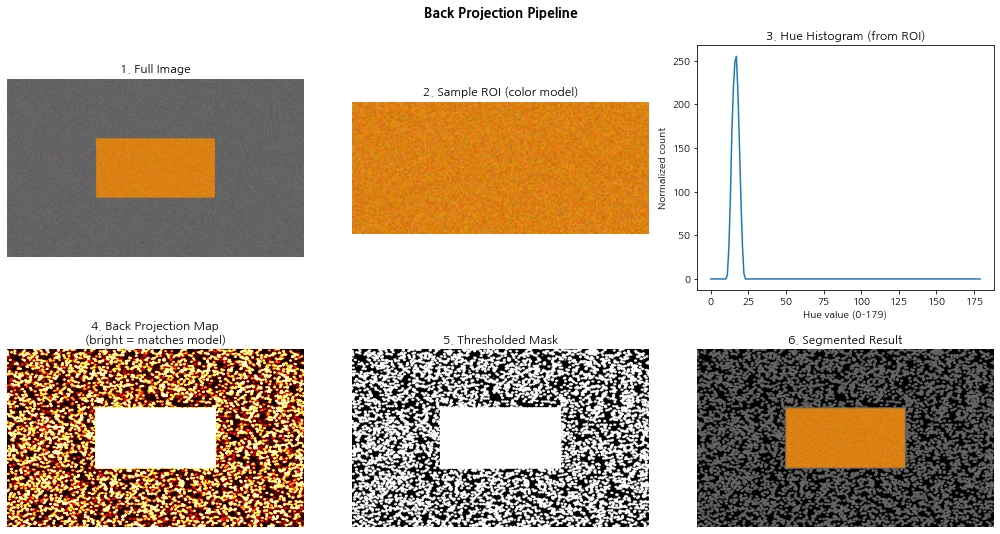

Saved: back_projection_demo.png


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# PART 1: mixChannels demo — extract Hue channel
# ─────────────────────────────────────────────

def extract_hue_with_mixchannels(image_bgr):
    """
    Demonstrates cv2.mixChannels by extracting only the Hue channel
    from an HSV image — equivalent to cv::mixChannels in C++.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    
    # Create a single-channel destination image (same size)
    hue = np.zeros((hsv.shape[0], hsv.shape[1]), dtype=hsv.dtype)
    
    # mixChannels takes:
    #   src list, dst list, fromTo mapping
    #   fromTo: [src_channel, dst_channel, src_channel, dst_channel, ...]
    #   HSV channel 0 = Hue → destination channel 0
    cv2.mixChannels(
        src=[hsv],
        dst=[hue],
        fromTo=[0, 0]   # copy channel 0 of src → channel 0 of dst
    )
    return hue


# ─────────────────────────────────────────────
# PART 2: Build histogram from a sample (ROI)
# ─────────────────────────────────────────────

def compute_hue_histogram(sample_bgr):
    """
    Convert sample to HSV, extract Hue channel,
    and compute a 1D histogram over Hue values.
    """
    hsv_sample = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2HSV)
    hue_sample = extract_hue_with_mixchannels(sample_bgr)
    
    # calcHist args: images, channels, mask, histSize, ranges
    hist = cv2.calcHist(
        images=[hue_sample],
        channels=[0],
        mask=None,
        histSize=[180],   # Hue range is 0–179 in OpenCV
        ranges=[0, 180]
    )
    
    # Normalize to [0, 255] so back projection gives intensity values
    cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)
    return hist


# ─────────────────────────────────────────────
# PART 3: Back Projection
# ─────────────────────────────────────────────

def back_project(target_bgr, hist):
    """
    Given a histogram model and a target image,
    compute the back projection (probability map).
    """
    hsv_target = cv2.cvtColor(target_bgr, cv2.COLOR_BGR2HSV)
    hue_target = extract_hue_with_mixchannels(target_bgr)
    
    # calcBackProject args: images, channels, hist, ranges, scale
    back_proj = cv2.calcBackProject(
        images=[hue_target],
        channels=[0],
        hist=hist,
        ranges=[0, 180],
        scale=1           # scale factor applied to each bin value
    )
    
    # Optional: apply a small disc kernel to smooth the result
    disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cv2.filter2D(back_proj, -1, disc, back_proj)
    
    return back_proj


# ─────────────────────────────────────────────
# PART 4: Demonstrate with synthetic data
# ─────────────────────────────────────────────

def demo():
    # Create a synthetic image: orange square on gray background
    # This simulates "we know the object color (orange), find it"
    full_image = np.ones((300, 500, 3), dtype=np.uint8) * 100  # gray background
    
    # Orange region (our "object")
    full_image[100:200, 150:350] = [20, 130, 220]  # BGR ≈ orange
    
    # Add some noise
    noise = np.random.randint(-20, 20, full_image.shape, dtype=np.int16)
    full_image = np.clip(full_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    # Sample ROI — pretend we "know" this small patch is our target object
    sample_roi = full_image[110:190, 160:340]
    
    # Step 1: Build histogram from sample
    hist = compute_hue_histogram(sample_roi)
    
    # Step 2: Back project onto the full image
    prob_map = back_project(full_image, hist)
    
    # Step 3: Threshold to get a binary mask
    _, mask = cv2.threshold(prob_map, 50, 255, cv2.THRESH_BINARY)
    
    # Step 4: Apply mask to original
    result = cv2.bitwise_and(full_image, full_image, mask=mask)
    
    # ── Visualization ──
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle("Back Projection Pipeline", fontsize=14, fontweight='bold')
    
    axes[0, 0].imshow(cv2.cvtColor(full_image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("1. Full Image")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cv2.cvtColor(sample_roi, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title("2. Sample ROI (color model)")
    axes[0, 1].axis('off')
    
    axes[0, 2].plot(hist)
    axes[0, 2].set_title("3. Hue Histogram (from ROI)")
    axes[0, 2].set_xlabel("Hue value (0–179)")
    axes[0, 2].set_ylabel("Normalized count")
    
    axes[1, 0].imshow(prob_map, cmap='hot')
    axes[1, 0].set_title("4. Back Projection Map\n(bright = matches model)")
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(mask, cmap='gray')
    axes[1, 1].set_title("5. Thresholded Mask")
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title("6. Segmented Result")
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig("back_projection_demo.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: back_projection_demo.png")


if __name__ == "__main__":
    demo()

In [3]:
hand_sample = cv2.imread(r'Data\hand.jpg')

hue_target = extract_hue_with_mixchannels(hand_sample)

In [6]:
cv2.imshow("hue", hue_target)
cv2.waitKey()
cv2.destroyAllWindows()

In [7]:
import cv2 as cv
import numpy as np

# Load image
img = cv.imread(r"Data\hand.jpg")
if img is None:
    raise FileNotFoundError("Could not load image.jpg")

# Convert BGR to HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Extract Hue channel using mixChannels
hue = np.empty((hsv.shape[0], hsv.shape[1]), dtype=hsv.dtype)
cv.mixChannels([hsv], [hue], fromTo=[0, 0])

# Build histogram from a region of interest
# Example ROI: center rectangle
h, w = hue.shape
x0, y0 = w // 4, h // 4
x1, y1 = 3 * w // 4, 3 * h // 4
roi = hue[y0:y1, x0:x1]

hist_size = [30]
ranges = [0, 180]
hist = cv.calcHist([roi], [0], None, hist_size, ranges)

# Normalize histogram before back projection
cv.normalize(hist, hist, 0, 255, cv.NORM_MINMAX)

# Back projection on the full Hue channel
backproj = cv.calcBackProject([hue], [0], hist, ranges, scale=1)

# Optional: smooth and threshold
backproj = cv.GaussianBlur(backproj, (5, 5), 0)
_, mask = cv.threshold(backproj, 50, 255, cv.THRESH_BINARY)

cv.imshow("Original", img)
cv.imshow("Back Projection", backproj)
cv.imshow("Thresholded Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()